In [1]:
# ============ #
# 1. LIBRERÍAS #
# ============ #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error


In [2]:
# =================== #
# 2. LECTURA DE RUTAS #
# =================== #

mainpath = os.path.join(os.getcwd(), "..", "..", "data", "raw")
filename = "job_salary_prediction_dataset.csv"
fullpath = os.path.join(mainpath, filename)


In [3]:
# ================= #
# 3. CARGA DE DATOS #
# ================= #

df = pd.read_csv(fullpath, sep=",")
pd.set_option('display.max_columns', None)


In [4]:
# ============================== #
# 4. IDENTIFICACIÓN DE VARIABLES #
# ============================== #

def variables(df = df):
    float_cols = df.select_dtypes(include='float64').columns.tolist()
    int_cols = df.select_dtypes(include='int64').columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    target = 'salary'
    features = [col for col in float_cols + int_cols if col != target]
    return features, target, cat_cols

features, target, cat_cols = variables()


C:\Users\saria\AppData\Local\Temp\ipykernel_21788\2578039198.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [5]:
# ================ #
# 5. PREPROCESADOR #
# ================ #

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), features)
])


In [6]:
# =============================== #
# VISUALIZAR EL PRE-PROCESAMIENTO #
# =============================== #

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [7]:
# ========================= #
# 6. PARTICIÓN TRAIN / TEST #
# ========================= #

X = df[features + cat_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [8]:
# ============ #
# 7. MODELO LIGHTGBM #
# ============ #

model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LGBMRegressor(random_state=42))
])

model.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 127
[LightGBM] [Info] Number of data points in the train set: 175000, number of used features: 42
[LightGBM] [Info] Start training from score 145687.018737


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [9]:
# ============== #
# 8. EVALUACIÓN  #
# ============== #

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("MAPE(%):", mape * 100)
print("R2:", r2)


MAE: 4432.605131951135
RMSE: 5579.074571336306
MAPE: 0.032561063390679386
MAPE(%): 3.2561063390679386
R2: 0.9776643927550803


c:\Users\saria\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [10]:
# ======================================== #
# 8.1. DATAFRAME CON RESULTADOS Y ERRORES  #
# ======================================== #

X_test_df = pd.DataFrame(X_test).reset_index(drop=True)
y_test_df = pd.Series(y_test).reset_index(drop=True)
y_pred_df = pd.Series(y_pred)

df_resultados = X_test_df.copy()
df_resultados["y_real"] = y_test_df
df_resultados["y_pred"] = y_pred_df
df_resultados["error"] = df_resultados["y_real"] - df_resultados["y_pred"]
df_resultados["abs_error"] = df_resultados["error"].abs()

df_resultados.sample(20)


,experience_years,skills_count,certifications,job_title,education_level,industry,company_size,location,remote_work,y_real,y_pred,error,abs_error
29050,11,1,2,Cybersecurity Analyst,Bachelor,Government,Medium,Remote,Yes,130900,134474.704975,-3574.704975,3574.704975
32124,18,16,0,Backend Developer,Master,Telecom,Large,Sweden,Yes,172244,179801.566805,-7557.566805,7557.566805
70590,11,14,1,AI Engineer,Master,Media,Medium,Australia,Yes,174685,176511.819575,-1826.819575,1826.819575
57666,2,6,1,Backend Developer,Diploma,Manufacturing,Large,USA,Yes,138551,141637.707260,-3086.707260,3086.707260
19312,10,8,0,Backend Developer,PhD,Telecom,Enterprise,UK,Hybrid,207197,194515.077256,12681.922744,12681.922744
9123,4,19,0,Business Analyst,Bachelor,Healthcare,Enterprise,USA,Hybrid,152404,150902.848516,1501.151484,1501.151484
59505,15,19,1,Cloud Engineer,High School,Manufacturing,Large,Sweden,Yes,161685,165193.171598,-3508.171598,3508.171598
5465,1,14,4,Data Analyst,High School,Retail,Small,USA,Hybrid,93343,105506.645541,-12163.645541,12163.645541
55502,17,18,1,AI Engineer,Bachelor,Manufacturing,Large,India,No,133037,139721.029393,-6684.029393,6684.029393
44659,3,7,1,Software Engineer,Master,Media,Small,UK,No,118485,124588.165463,-6103.165463,6103.165463


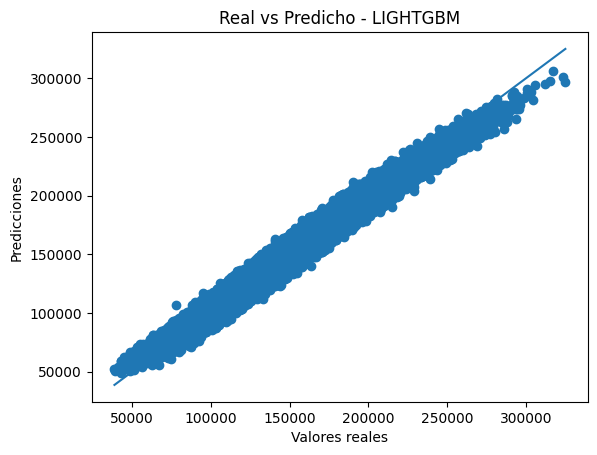

In [11]:
# ====================== #
# 8.2. REAL VS PREDICHO  #
# ====================== #

plt.scatter(df_resultados["y_real"], df_resultados["y_pred"])
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho - LIGHTGBM")
plt.plot(
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()],
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()]
)
plt.show()


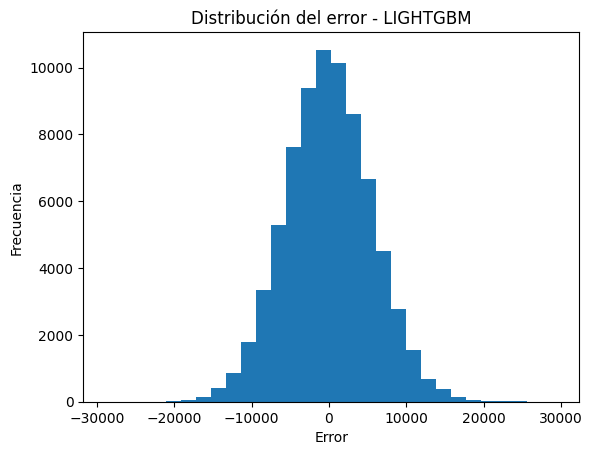

In [12]:
# ============================= #
# 8.3. DISTRIBUCIÓN DE ERRORES  #
# ============================= #

plt.hist(df_resultados["error"], bins=30)
plt.title("Distribución del error - LIGHTGBM")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()


In [15]:
import warnings
from sklearn.model_selection import cross_validate
import numpy as np

# 1. Silenciamos advertencias de librerías y mensajes de LightGBM
warnings.filterwarnings('ignore')

# Actualizamos el modelo para que no imprima logs innecesarios
# Asegúrate de que 'model' ya esté definido antes de esta celda
if hasattr(model, 'set_params'):
    model.set_params(regressor__verbose=-1)

# 2. Definimos las métricas de evaluación
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

# 3. Ejecutamos la validación cruzada (10-Fold)
# Nota: Esto puede tardar un poco dependiendo de tu PC
cv_results = cross_validate(model, X_train, y_train, cv=10, scoring=scoring)

# 4. Procesamos y formateamos los resultados
mae_scores = -cv_results['test_mae']
rmse_scores = -cv_results['test_rmse']
r2_scores = cv_results['test_r2']

# 5. Imprimimos el reporte final
print("="*40)
print("   RESULTADOS LIGHTGBM (VALIDACIÓN CRUZADA)   ")
print("="*40)
print(f"MAE  Promedio: {mae_scores.mean():.2f} (±{mae_scores.std():.2f})")
print(f"RMSE Promedio: {rmse_scores.mean():.2f} (±{rmse_scores.std():.2f})")
print(f"R²   Promedio: {r2_scores.mean():.4f} (±{r2_scores.std():.4f})")
print("="*40)

   RESULTADOS LIGHTGBM (VALIDACIÓN CRUZADA)   
MAE  Promedio: 4462.97 (±37.54)
RMSE Promedio: 5617.79 (±43.71)
R²   Promedio: 0.9775 (±0.0004)


In [18]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Definimos los parámetros a probar
param_dist_lgbm = {
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__num_leaves': [31, 50, 70],
    'regressor__verbosity': [-1]
}

# 2. Búsqueda aleatoria (probaremos 5 combinaciones para que no tarde una hora)
random_search_lgbm = RandomizedSearchCV(
    model, 
    param_distributions=param_dist_lgbm, 
    n_iter=5, 
    cv=5, 
    scoring='r2', 
    random_state=42
)

random_search_lgbm.fit(X_train, y_train)

print(f"Mejor R² LightGBM: {random_search_lgbm.best_score_:.4f}")
print(f"Mejores parámetros: {random_search_lgbm.best_params_}")

Mejor R² LightGBM: 0.9677
Mejores parámetros: {'regressor__verbosity': -1, 'regressor__num_leaves': 70, 'regressor__n_estimators': 100, 'regressor__learning_rate': 0.05}


In [19]:
# 1. Parámetros a tunear
param_dist_lgbm = {
    'regressor__n_estimators': [100, 200, 500],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__num_leaves': [20, 31, 50],
    'regressor__verbosity': [-1]
}

# 2. Búsqueda con CV
random_lgbm = RandomizedSearchCV(
    model, 
    param_distributions=param_dist_lgbm, 
    n_iter=10, # Probará 10 combinaciones al azar
    cv=5, 
    scoring='neg_mean_absolute_error',
    random_state=42
)

random_lgbm.fit(X_train, y_train)
print(f"Mejor configuración LightGBM: {random_lgbm.best_params_}")

Mejor configuración LightGBM: {'regressor__verbosity': -1, 'regressor__num_leaves': 50, 'regressor__n_estimators': 500, 'regressor__learning_rate': 0.05}


In [20]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Predicción con el modelo original (el que estaba sin ajustar)
y_pred_base = model.predict(X_test)

# 2. Predicción con el modelo ajustado (el mejor que encontró RandomizedSearch)
# Usamos .best_estimator_ que ya tiene los parámetros optimizados
best_lgbm = random_lgbm.best_estimator_
y_pred_tuned = best_lgbm.predict(X_test)

# 3. Cálculo de métricas
mae_base = mean_absolute_error(y_test, y_pred_base)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

# 4. Reporte comparativo para el Ítem C y D
print("-" * 30)
print(" COMPARATIVA LIGHTGBM ")
print("-" * 30)
print(f"MAE Inicial:   {mae_base:.2f}")
print(f"MAE Ajustado:  {mae_tuned:.2f}")
print(f"R2 Ajustado:   {r2_tuned:.4f}")
print("-" * 30)

if mae_tuned < mae_base:
    print(f"¡Éxito! El error bajó en {mae_base - mae_tuned:.2f} unidades.")
else:
    print("El modelo base ya era óptimo o el ajuste fue muy ligero.")

------------------------------
 COMPARATIVA LIGHTGBM 
------------------------------
MAE Inicial:   4432.61
MAE Ajustado:  4140.57
R2 Ajustado:   0.9807
------------------------------
¡Éxito! El error bajó en 292.04 unidades.
